In [17]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

In [18]:
import logging

logging.basicConfig(level=logging.INFO)

logger = logging.getLogger(__name__)

In [3]:
from src.IO.video import load_vid

# frames = load_vid("People Walking Free Stock Footage, Royalty-Free No Copyright Content.mp4", selected_frames=range(0, 420, 60))
frames = load_vid("People Walking Free Stock Footage, Royalty-Free No Copyright Content.mp4", selected_frames=range(0, 180, 90))
len(frames)

INFO:src.IO.video:FPS: 29.97002997002997


2

In [ ]:
from segmentation import segment_people_batch

frames_masked, frames_masks = segment_people_batch(frames, batch_size=2)

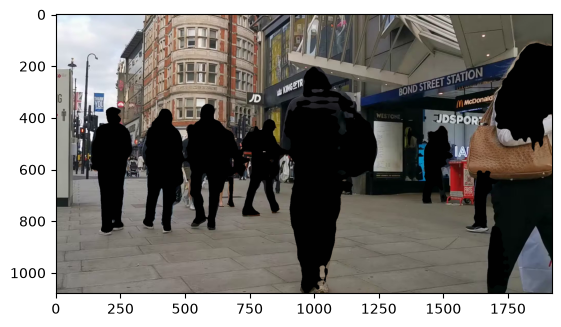

In [8]:
img = cv2.cvtColor(frames_masked[0], cv2.COLOR_BGR2RGB)
plt.imshow(img)

In [ ]:
from segmentation import segment_people_batch

frames_masked, frames_masks = segment_people_batch(frames)

from src.filters import mean_non_masked

mean_img = mean_non_masked(frames_masked, frames_masks)

from src.filters import smooth_image

smooth_img = smooth_image(mean_img, kernel_size=5)

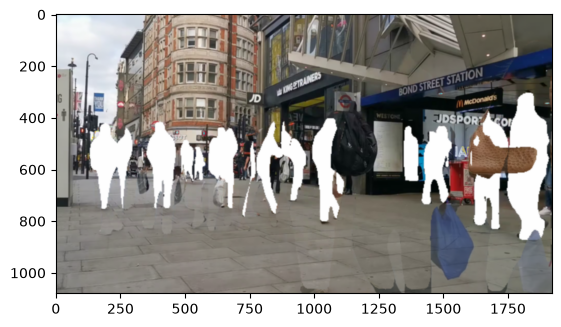

In [7]:
plt.imshow(cv2.cvtColor(smooth_img, cv2.COLOR_BGR2RGB))
plt.show()

In [40]:
mask_three_channels = np.stack([frames_masks]*3, axis=-1)
t, h, w, c = frames_masked.shape
masked_mean_img = np.zeros((h, w, c), dtype=np.uint8)

for hi in range(h):
    for wi in range(w):
        for ci in range(c):
            channel_values = []
            for ti in range(t):
                show = mask_three_channels[ti, hi, wi, ci]
                if show == 0:
                    continue
                elif show == 255:
                    channel_values.append(frames_masked[ti, hi, wi, ci])
            mean = np.mean(channel_values) if channel_values != [] else 0
            masked_mean_img[hi, wi, ci] = mean

KeyboardInterrupt: 

C:\Users\Cyril\AppData\Local\Temp\ipykernel_13988\60443229.py:5: RuntimeWarning: invalid value encountered in divide
  mean = masked_sum / counts


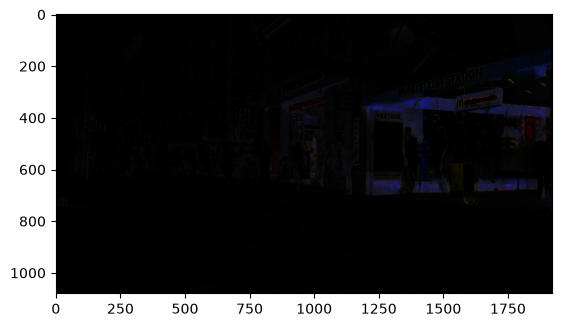

In [17]:
def mean_non_masked(frames_masked, frames_masks):
    frames_masks_three_channels = np.stack([frames_masks]*3, axis=-1, dtype=np.uint8)
    masked_sum = np.sum(frames_masked * frames_masks_three_channels, axis=0, dtype=np.float32)
    counts = np.sum(frames_masked, axis=0, dtype=np.float32)
    mean = masked_sum / counts
    mean = np.nan_to_num(mean, nan=0.0)
    mean = mean.astype(np.uint8)
    return mean

import numpy as np
mean_img = mean_non_masked(frames_masked, frames_masks)
plt.imshow(mean_img)

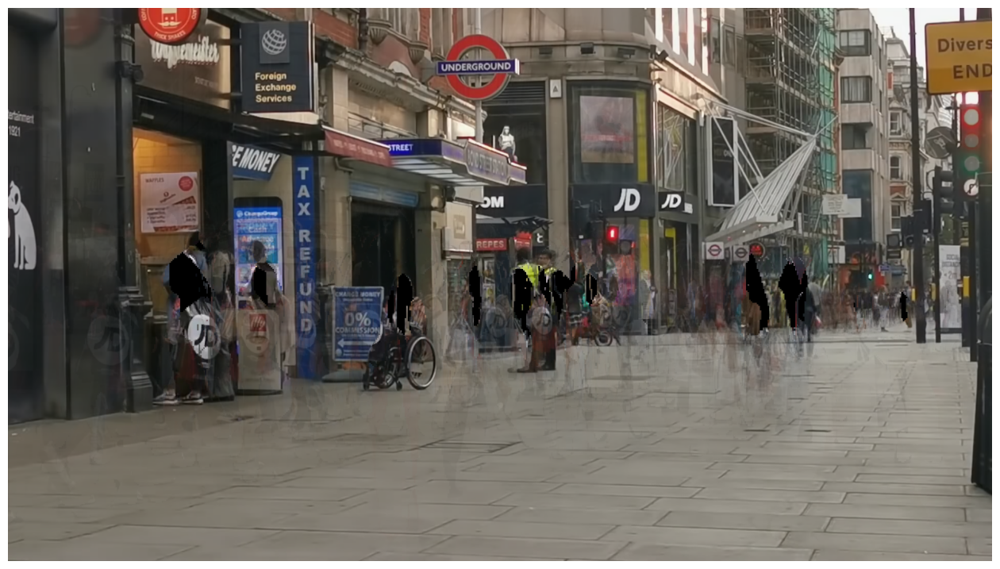

In [110]:
def mean_background(frames, frames_masks):
    frames_array = np.asarray(frames, dtype=np.float32)

    # Background pixels are 0 in the person mask.
    background = (~frames_masks == 0).astype(np.float32)
    background = background[..., None]

    pixel_sum = np.sum(frames_array * background, axis=0)
    pixel_count = np.sum(background, axis=0)

    mean = np.divide(
        pixel_sum,
        pixel_count,
        out=np.zeros_like(pixel_sum),
        where=pixel_count != 0,
    )

    return mean.astype(np.uint8)

mean_img = mean_background(frames, frames_masks)

mean_img_rgb = cv2.cvtColor(mean_img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(16, 10))
plt.imshow(mean_img_rgb)
plt.axis("off")
plt.show()

In [112]:
frames, frames_masks

([array([[[133, 131, 127],
          [133, 131, 127],
          [133, 131, 127],
          ...,
          [ 64,  68,  77],
          [ 80,  84,  93],
          [119, 123, 132]],
  
         [[133, 131, 127],
          [133, 131, 127],
          [133, 131, 127],
          ...,
          [ 64,  68,  77],
          [ 80,  84,  93],
          [119, 123, 132]],
  
         [[133, 131, 127],
          [133, 131, 127],
          [133, 131, 127],
          ...,
          [ 64,  68,  77],
          [ 80,  84,  93],
          [119, 123, 132]],
  
         ...,
  
         [[107, 115, 119],
          [107, 115, 119],
          [107, 115, 119],
          ...,
          [117, 126, 132],
          [117, 126, 132],
          [117, 126, 132]],
  
         [[101, 109, 113],
          [101, 109, 113],
          [101, 109, 113],
          ...,
          [117, 126, 132],
          [117, 126, 132],
          [117, 126, 132]],
  
         [[ 99, 107, 111],
          [ 99, 107, 111],
          [ 99, 107, 111

In [113]:
t, h, w, c = np.array(frames).shape
mode_img = np.zeros((h, w, c))
mode_img.shape

(1080, 1920, 3)

In [114]:
nb_computations = h * w * t * c
print(nb_computations)

87091200


In [115]:
nb_done = 0
for hi in range(h):
    for wi in range(w):
        for ti in range(t):
            for ci in range(c):
                mode_vector_cell = []
                if frames_masks[ti, hi, wi] == 255:
                    mode_vector_cell.append(np.array(frames)[ti, hi, wi, ci])
                mode = np.bincount(mode_vector_cell).argmax()
                mode_img[hi, wi, ci] = mode
                nb_done += 1

                if nb_done %100 == 0:
                    print(f"end={nb_done}/{nb_computations} ({nb_done/nb_computations*100:.2f}%)")

KeyboardInterrupt: 

In [116]:
from numba import njit, prange

prange(10)

range(0, 10)

In [117]:
@njit(parallel=True)
def masked_mode(frames, masks):          # frames: (t,h,w,c) uint8, masks: (t,h,w)
    t, h, w, c = frames.shape
    out = np.zeros((h, w, c), np.uint8)
    for hi in prange(h):
        hist = np.zeros(256, np.int32)
        for wi in range(w):
            for ci in range(c):
                hist[:] = 0
                for ti in range(t):
                    if masks[ti, hi, wi] == 255:
                        hist[frames[ti, hi, wi, ci]] += 1
                out[hi, wi, ci] = np.argmax(hist)   # smallest value wins ties, same as bincount.argmax
    return out

mode_img = masked_mode(np.asarray(frames), frames_masks)

In [118]:
from tqdm import tqdm   # or use print as below

frames = np.asarray(frames)
t, h, w, c = frames.shape
mode_img = np.zeros((h, w, c), np.uint8)
step = max(1, h // 100)                      # ~100 progress updates

for h0 in range(0, h, step):
    h1 = min(h0 + step, h)
    mode_img[h0:h1] = masked_mode(frames[:, h0:h1], frames_masks[:, h0:h1])
    done = h1 * w * t * c
    print(f"end={done}/{t*h*w*c} ({done/(t*h*w*c)*100:.2f}%)")

end=806400/87091200 (0.93%)
end=1612800/87091200 (1.85%)
end=2419200/87091200 (2.78%)
end=3225600/87091200 (3.70%)
end=4032000/87091200 (4.63%)
end=4838400/87091200 (5.56%)
end=5644800/87091200 (6.48%)
end=6451200/87091200 (7.41%)
end=7257600/87091200 (8.33%)
end=8064000/87091200 (9.26%)
end=8870400/87091200 (10.19%)
end=9676800/87091200 (11.11%)
end=10483200/87091200 (12.04%)
end=11289600/87091200 (12.96%)
end=12096000/87091200 (13.89%)
end=12902400/87091200 (14.81%)
end=13708800/87091200 (15.74%)
end=14515200/87091200 (16.67%)
end=15321600/87091200 (17.59%)
end=16128000/87091200 (18.52%)
end=16934400/87091200 (19.44%)
end=17740800/87091200 (20.37%)
end=18547200/87091200 (21.30%)
end=19353600/87091200 (22.22%)
end=20160000/87091200 (23.15%)
end=20966400/87091200 (24.07%)
end=21772800/87091200 (25.00%)
end=22579200/87091200 (25.93%)
end=23385600/87091200 (26.85%)
end=24192000/87091200 (27.78%)
end=24998400/87091200 (28.70%)
end=25804800/87091200 (29.63%)
end=26611200/87091200 (30.56%)


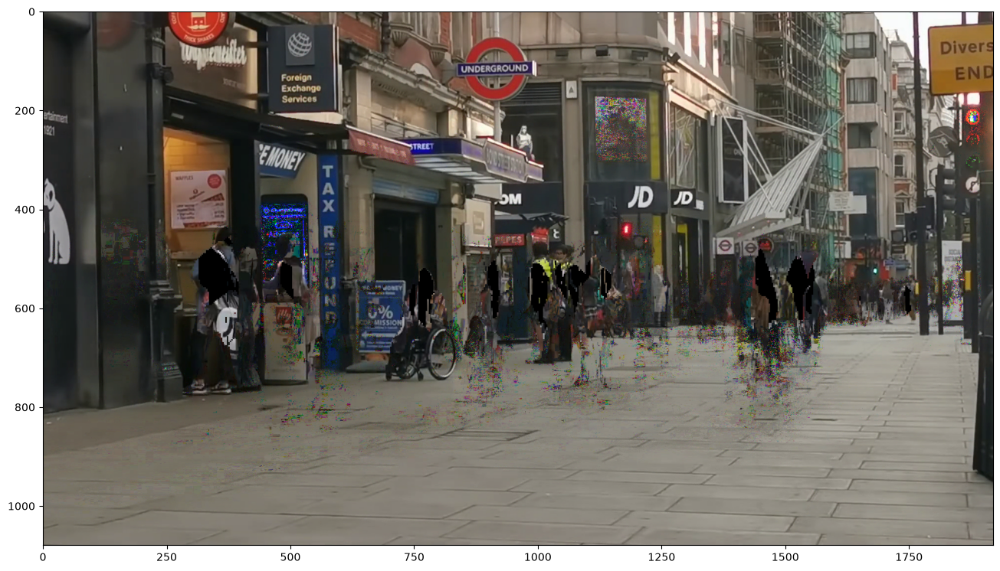

In [119]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 10))
plt.imshow(cv2.cvtColor(mode_img, cv2.COLOR_BGR2RGB))

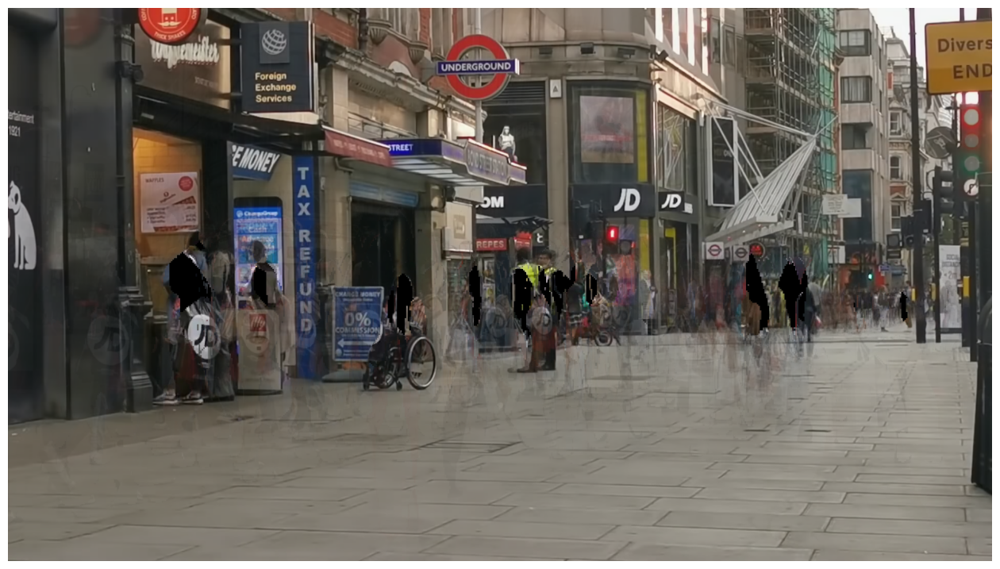

In [120]:
def mean_background(frames, frames_masks):
    frames_array = np.asarray(frames, dtype=np.float32)

    # Background pixels are 0 in the person mask.
    background = (~frames_masks == 0).astype(np.float32)
    background = background[..., None]

    pixel_sum = np.sum(frames_array * background, axis=0)
    pixel_count = np.sum(background, axis=0)

    mean = np.divide(
        pixel_sum,
        pixel_count,
        out=np.zeros_like(pixel_sum),
        where=pixel_count != 0,
    )

    return mean.astype(np.uint8)

mean_img = mean_background(frames, frames_masks)

mean_img_rgb = cv2.cvtColor(mean_img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(16, 10))
plt.imshow(mean_img_rgb)
plt.axis("off")
plt.show()

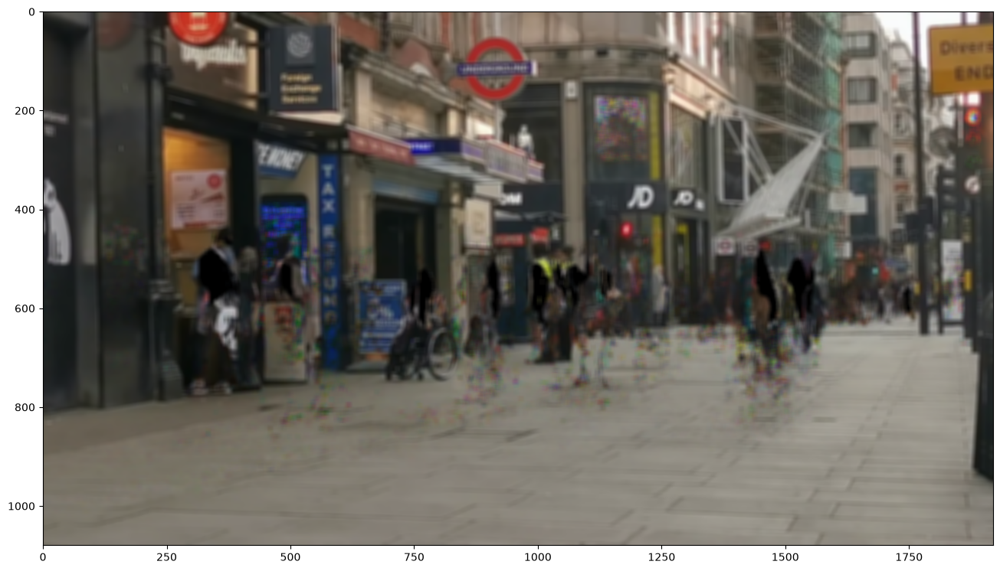

In [121]:
smoothed_img = cv2.blur(mode_img, ksize=(11, 11))
plt.figure(figsize=(16, 10))
plt.imshow(cv2.cvtColor(smoothed_img, cv2.COLOR_BGR2RGB))

In [18]:
# shittiest code this world has ever seen, but it works and I don't care
# import numpy as np

# all_frames = np.array(frames)

# nb_img, h, w, c = all_frames.shape

# med_grid = np.zeros((h, w, c), dtype=np.uint8)

# for i in range(h):
#     for j in range(w):
#         for c in range(3):
#             med = all_frames[:, i, j, c] # : for all images, i, j to select position, c for color channel
#             med = np.median(med, axis=0)
#             med_grid[i, j, c] = med

In [19]:
import numpy as np

all_frames = np.array(frames)          # shape: (nb_img, h, w, c)

med_grid = np.median(all_frames, axis=0).astype(np.uint8)  # shape: (h, w, c)

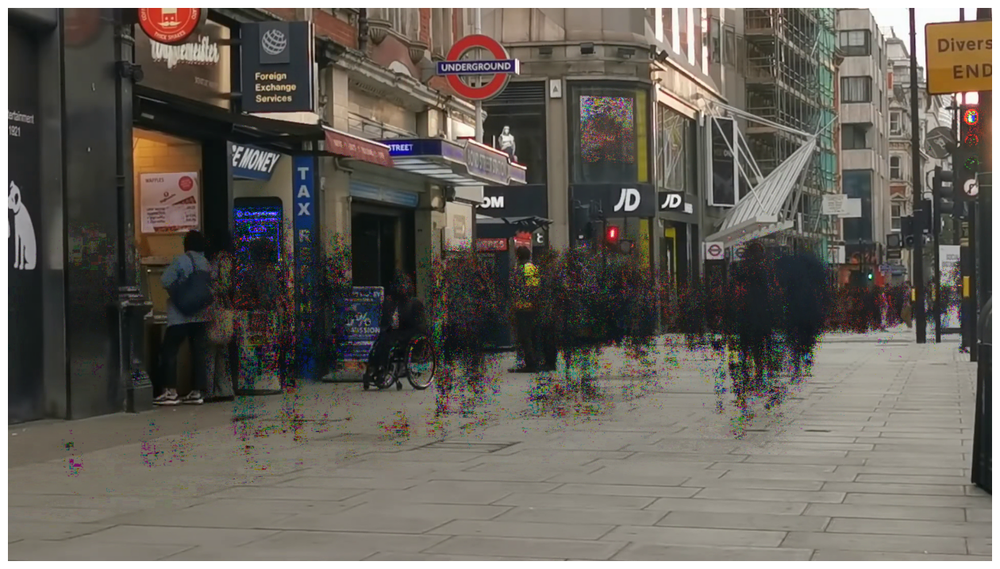

In [122]:
import cv2
import matplotlib.pyplot as plt

from src.utils.temporal_filters import temporal_mode

mode_grid = temporal_mode(frames)
img = cv2.cvtColor(mode_grid, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(16, 10))
plt.imshow(img)
plt.axis('off')
plt.show()

In [123]:
import cv2
import matplotlib.pyplot as plt

img = cv2.cvtColor(med_grid, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(16, 10))
plt.imshow(img)
plt.axis('off')
plt.show()

NameError: name 'med_grid' is not defined

In [4]:
# edit video sma ?

In [ ]:
import numpy as np

a = np.array([
    [1, 2],
    [3, 4]
])

b = np.array([
    [5, 6],
    [7, 8]
])
all_frames = np.stack((a, b), axis=0)

h, w = a.shape
med = np.zeros((h, w), dtype=np.uint8)

for i in range(h):
    for j in range(w):
        med[i, j] = np.median([all_frames[img_idx, i, j] for img_idx in range(all_frames.shape[0])])

med

In [ ]:
# Median filtering across time
# Mode (most frequent value)

In [15]:
stack = np.stack((a, b), axis=0)
stack

array([[[1, 2],
        [3, 4]],

       [[5, 6],
        [7, 8]]])

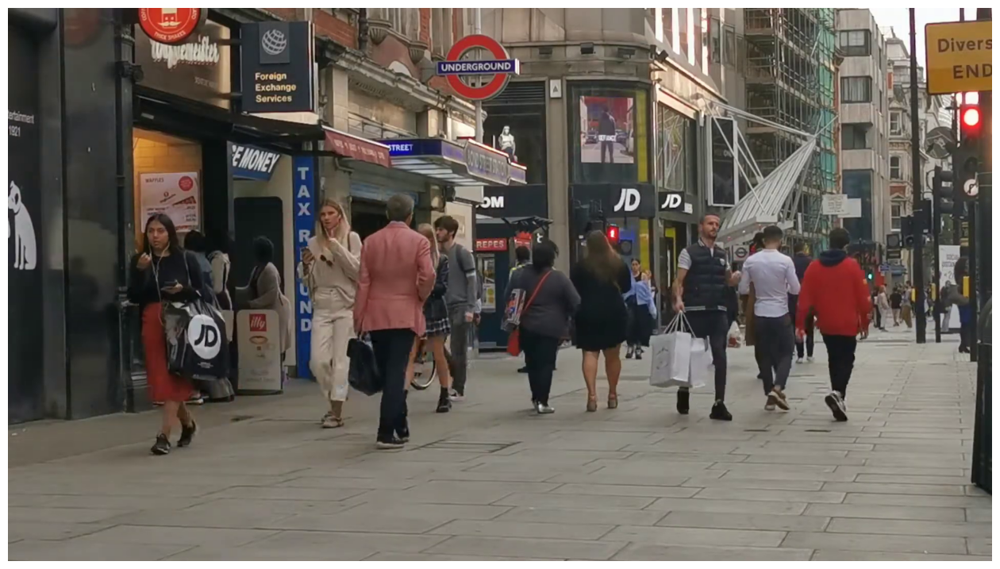

In [125]:
import matplotlib.pyplot as plt

img = cv2.cvtColor(frames[10], cv2.COLOR_BGR2RGB)

plt.figure(figsize=(16,10))
plt.imshow(img)
plt.axis("off")
plt.show()

In [126]:
@njit(parallel=True)
def masked_mode_mean(frames, masks, min_mode_count=7):
    t, h, w, c = frames.shape
    out = np.zeros((h, w, c), np.uint8)
    for hi in prange(h):
        hist = np.zeros(256, np.int32)
        for wi in range(w):
            for ci in range(c):
                hist[:] = 0
                s = 0
                n = 0
                for ti in range(t):
                    if masks[ti, hi, wi] == 255:
                        v = frames[ti, hi, wi, ci]
                        hist[v] += 1
                        s += v
                        n += 1
                m = np.argmax(hist)
                if hist[m] >= min_mode_count:
                    out[hi, wi, ci] = m            # mode is well supported
                elif n > 0:
                    out[hi, wi, ci] = s // n       # fallback: mean (truncated, like mean_background)
                # n == 0: no valid sample, stays 0
    return out

frames = np.asarray(frames)
t, h, w, c = frames.shape
mode_img = np.zeros((h, w, c), np.uint8)
step = max(1, h // 100)
for h0 in range(0, h, step):
    h1 = min(h0 + step, h)
    mode_img[h0:h1] = masked_mode_mean(frames[:, h0:h1], frames_masks[:, h0:h1], 3)
    # print(f"{h1/h*100:.1f}%")

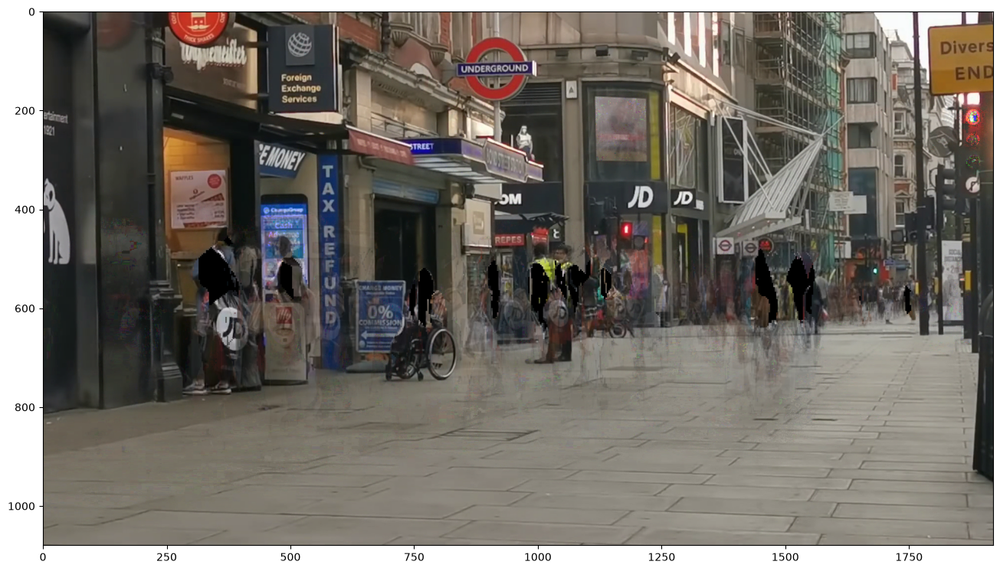

In [127]:
img = cv2.cvtColor(mode_img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(16, 10))
plt.imshow(img)
plt.show()

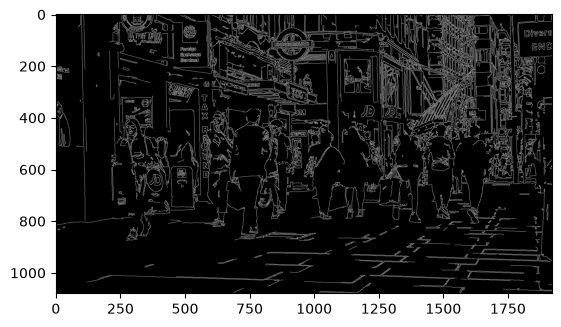

In [130]:
img = frames[10]
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
edges = cv2.Canny(img_gray, 50, 150)
plt.imshow(edges, cmap='gray')

In [174]:
def segmentation_differencing(frames: np.ndarray):
    frames_masked = []
    masks = []
    for i in range(1, len(frames)):
        curr = cv2.cvtColor(frames[i], cv2.COLOR_BGR2RGB)
        prev = cv2.cvtColor(frames[i-1], cv2.COLOR_BGR2RGB)
        frame_diff = cv2.absdiff(curr, prev)
        frame_diff = np.array(frame_diff, dtype=np.uint8)
        frame_diff = np.where(frame_diff > 25, 0, 1).astype(np.bool)
        masks.append(frame_diff)
        frames_masked.append(curr * frame_diff)
    return frames_masked, masks

frames_masked, frames_masks = segmentation_differencing(frames)

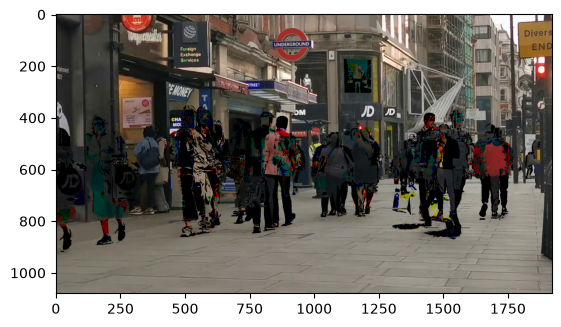

In [175]:
frames_masked = np.array(frames_masked)

plt.imshow(frames_masked[10], cmap='gray')

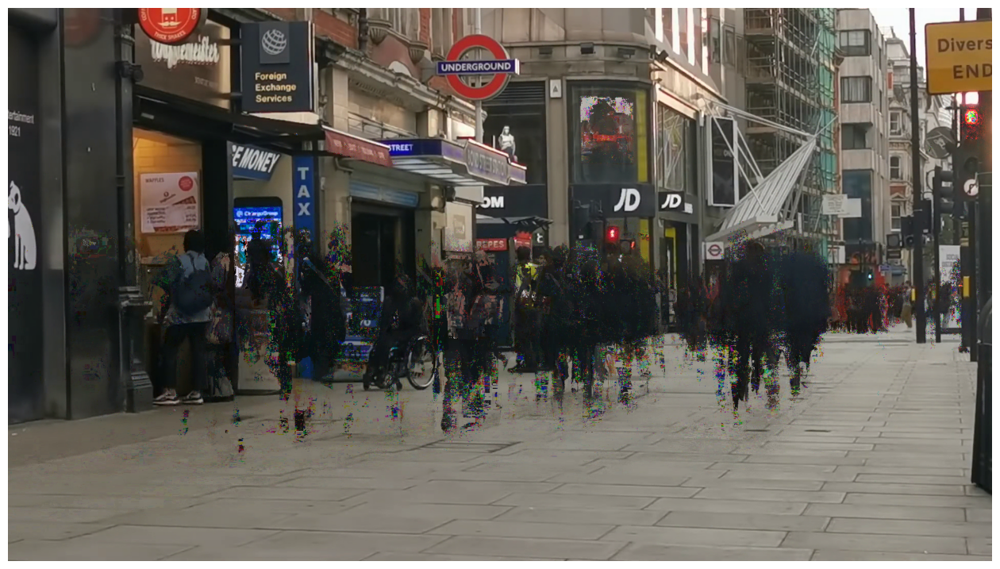

In [176]:
frames_masked, diff_masks = segmentation_differencing(frames)

# Collapse the per-channel boolean mask to one channel: "unchanged" only if
# all 3 channels had a small diff. Convert True/False -> 255/0 for masked_mode.
masks_flat = np.stack([m.all(axis=-1) for m in diff_masks]).astype(np.uint8) * 255

# Align frames with the masks: mask i corresponds to frames[i+1] (the "curr" frame).
frames_aligned = np.asarray(frames[1:])

mode_img = masked_mode(frames_aligned, masks_flat)

img = cv2.cvtColor(mode_img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(16, 10))
plt.imshow(img)
plt.axis("off")
plt.show()

In [12]:
SMOOTHERS = {
    "KERNEL": 1,
    "NONE": 2
}
img = SMOOTHERS.get(None)
print(img)

None


In [1]:
import matplotlib.pyplot as plt
import cv2

In [2]:
from src.IO.video import load_vid

# frames = load_vid("People Walking Free Stock Footage, Royalty-Free No Copyright Content.mp4", selected_frames=range(0, 420, 60))
frames = load_vid("People Walking Free Stock Footage, Royalty-Free No Copyright Content.mp4", selected_frames=range(0, 180, 90))
len(frames)

2

In [3]:
img = frames[0]
h, w, c = img.shape

In [4]:
from compression import compress, uncompress

INFO:compression:Original dimensions: 1920x1080, target dimensions: 150x100
INFO:compression:Original dimensions: 150x100, target dimensions: 1920x1080


Text(0.5, 1.0, 'Uncompressed')

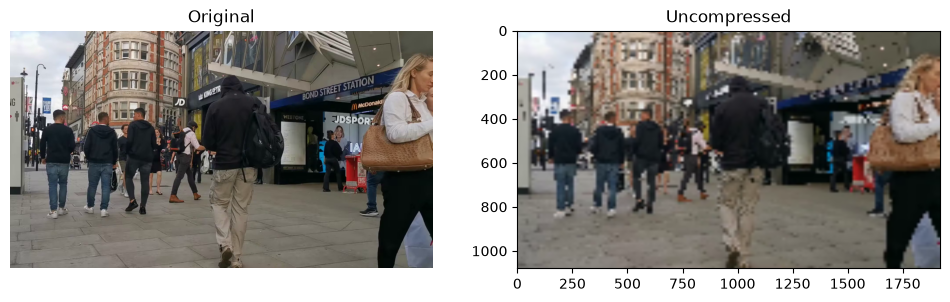

In [5]:

img = frames[0]
# plot side by sidee compressed and uncompressed images
img_manip = compress(img, (100, 150))
img_manip_uncompressed = uncompress(img_manip, (h, w))

fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Original image
ax[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
ax[0].set_title('Original')
ax[0].axis('off')

# Uncompressed image
ax[1].imshow(cv2.cvtColor(img_manip_uncompressed, cv2.COLOR_BGR2RGB))
ax[1].set_title('Uncompressed')

INFO:compression:Original dimensions: 1920x1080, target dimensions: 360x640
INFO:compression:Original dimensions: 1920x1080, target dimensions: 360x640
INFO:compression:Original dimensions: 360x640, target dimensions: 1920x1080


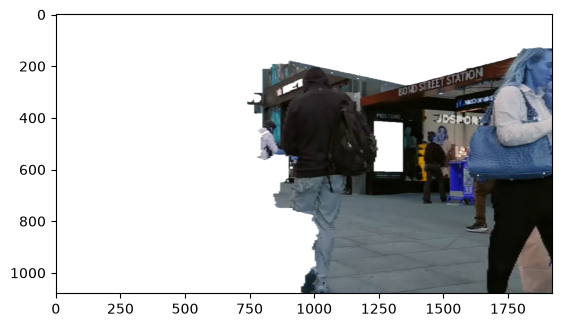

In [6]:
import cv2
import numpy as np

h_tmp, w_tmp = 360, 640
img_manip = compress(img, (w_tmp, h_tmp))

def process_image(img):
    margin = 0.05  # 5% margin
    x = int(w * margin)
    y = int(h * margin)
    rect = (x, y, w - 2*x, h - 2*y)


    mask = np.zeros(img.shape[:2], np.uint8)
    bgdModel = np.zeros((1, 65), np.float64)
    fgdModel = np.zeros((1, 65), np.float64)

    cv2.grabCut(img, mask, rect, bgdModel, fgdModel, 5, cv2.GC_INIT_WITH_RECT)

    mask2 = np.where((mask == 2) | (mask == 0), 0, 1).astype("uint8")

    output_rgba = cv2.cvtColor(img, cv2.COLOR_BGR2BGRA)
    output_rgba[:, :, 3] = mask2 * 255

    return output_rgba

h_original, w_original, _ = img.shape
img_compressed = compress(img, (w_tmp, h_tmp))
img_processed = process_image(img_compressed)
img_processed = uncompress(img_processed, (h_original, w_original))

plt.imshow(img_processed)

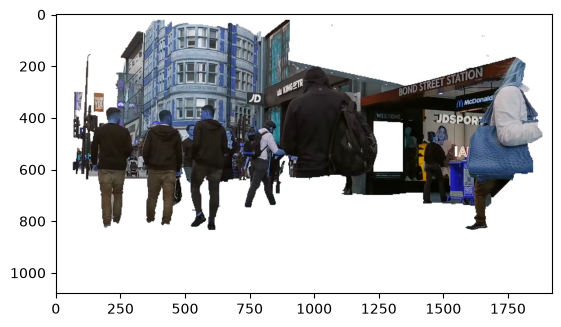

In [7]:
import cv2
import numpy as np

def resize_for_processing(img, target_size):
    """Downscale only (no round-trip). target_size = (height, width)."""
    h_target, w_target = target_size
    return cv2.resize(img, (w_target, h_target), interpolation=cv2.INTER_AREA)

def process_image(img):
    """Run GrabCut and return a binary foreground mask (same size as img)."""
    h, w = img.shape[:2]
    margin = 0.02
    x, y = int(w * margin), int(h * margin)
    rect = (x, y, w - 2 * x, h - 2 * y)

    mask = np.zeros((h, w), np.uint8)
    bgdModel = np.zeros((1, 65), np.float64)
    fgdModel = np.zeros((1, 65), np.float64)
    cv2.grabCut(img, mask, rect, bgdModel, fgdModel, 20, cv2.GC_INIT_WITH_RECT)

    return np.where((mask == cv2.GC_BGD) | (mask == cv2.GC_PR_BGD), 0, 1).astype(np.uint8)

def resize_mask_to_original(mask_small, original_size):
    """Upsample a binary mask; INTER_NEAREST keeps it strictly 0/1, no gray blending."""
    h_orig, w_orig = original_size
    return cv2.resize(mask_small, (w_orig, h_orig), interpolation=cv2.INTER_NEAREST)

# --- pipeline ---
h_original, w_original = img.shape[:2]

img_small = resize_for_processing(img, target_size=(360, 640))
mask_small = process_image(img_small)
mask_full = resize_mask_to_original(mask_small, (h_original, w_original))

output_rgba = cv2.cvtColor(img, cv2.COLOR_BGR2BGRA)   # original, full-res image
output_rgba[:, :, 3] = mask_full * 255

plt.imshow(output_rgba)

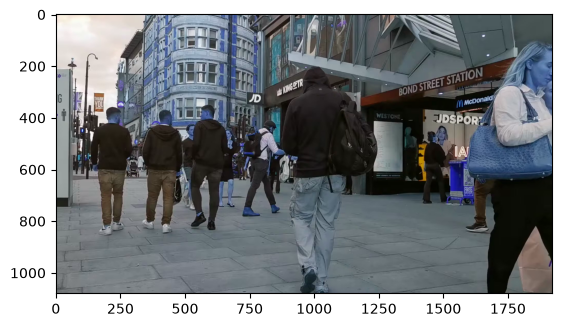

In [8]:
plt.imshow(frames[0])

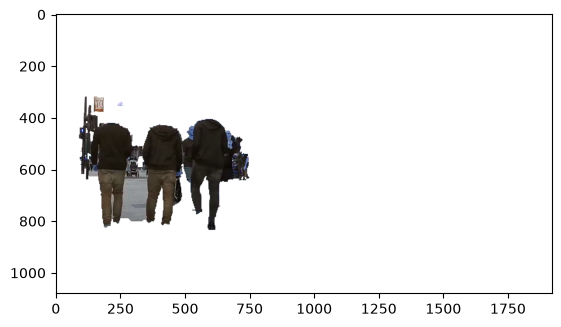

In [ ]:
def detect_person_boxes(img_bgr, scale_factor=1.1, min_neighbors=3):
    """Classical, non-DNN person detection via Haar cascade (full-body)."""
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    cascade_path = cv2.data.haarcascades + "haarcascade_fullbody.xml"
    detector = cv2.CascadeClassifier(cascade_path)
    boxes = detector.detectMultiScale(
        gray, scaleFactor=scale_factor, minNeighbors=min_neighbors
    )
    return [tuple(box) for box in boxes]  # each box: (x, y, w, h)


def grabcut_on_box(img, box, padding=10, iterations=5):
    """Run GrabCut seeded by one bounding box, return a 0/1 mask (full image size)."""
    h_img, w_img = img.shape[:2]
    x, y, w, h = box
    x0, y0 = max(x - padding, 0), max(y - padding, 0)
    x1, y1 = min(x + w + padding, w_img), min(y + h + padding, h_img)
    rect = (x0, y0, x1 - x0, y1 - y0)

    mask = np.zeros((h_img, w_img), np.uint8)
    bgdModel = np.zeros((1, 65), np.float64)
    fgdModel = np.zeros((1, 65), np.float64)
    cv2.grabCut(img, mask, rect, bgdModel, fgdModel, iterations, cv2.GC_INIT_WITH_RECT)

    return np.where((mask == cv2.GC_FGD) | (mask == cv2.GC_PR_FGD), 1, 0).astype(np.uint8)


def process_image(img):
    """Detect people (Haar cascade), then GrabCut each one individually."""
    boxes = detect_person_boxes(img)
    h, w = img.shape[:2]
    combined_mask = np.zeros((h, w), np.uint8)

    for box in boxes:
        person_mask = grabcut_on_box(img, box)
        combined_mask = np.maximum(combined_mask, person_mask)

    return combined_mask


# --- pipeline (still downscale first for speed) ---
def resize_for_processing(img, target_size):
    h_target, w_target = target_size
    return cv2.resize(img, (w_target, h_target), interpolation=cv2.INTER_AREA)

def resize_mask_to_original(mask_small, original_size):
    h_orig, w_orig = original_size
    return cv2.resize(mask_small, (w_orig, h_orig), interpolation=cv2.INTER_NEAREST)

h_original, w_original = img.shape[:2]
img_small = resize_for_processing(img, target_size=(360, 640))
mask_small = process_image(img_small)
mask_full = resize_mask_to_original(mask_small, (h_original, w_original))

output_rgba = cv2.cvtColor(img, cv2.COLOR_BGR2BGRA)
output_rgba[:, :, 3] = mask_full * 255
plt.imshow(output_rgba)

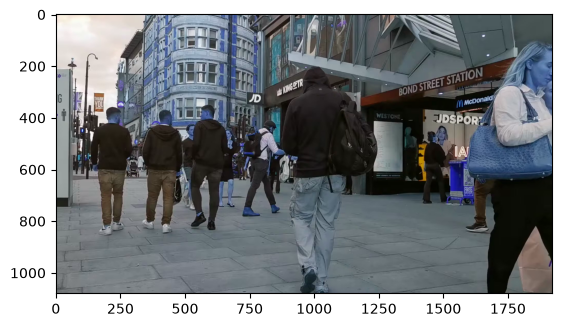

In [10]:
plt.imshow(img)

In [63]:
%%timeit
def segment_frame_differencing(imgs):
    # compute differences between frames
    frames_per_step = 30
    frames_diff = []
    for t in range(frames_per_step, len(frames), frames_per_step):
        diff = cv2.absdiff(frames[t], frames[t - frames_per_step])
        frames_diff.append(diff)
    return frames_diff

f_diff = segment_frame_differencing(frames)

47 ms ± 13.7 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [64]:
%%timeit
def segment_frame_differencing(imgs):
    frames_grey = [cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY) for frame in imgs]
    # compute differences between frames
    frames_per_step = 30
    frames_diff = []
    for t in range(frames_per_step, len(frames_grey), frames_per_step):
        diff = cv2.absdiff(frames_grey[t], frames_grey[t - frames_per_step])
        frames_diff.append(diff)
    return frames_diff

f_diff = segment_frame_differencing(frames)

441 ms ± 87.3 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [30]:
from src.IO.video import load_vid

frames = load_vid("People Walking Free Stock Footage, Royalty-Free No Copyright Content.mp4", selected_frames=range(0, 180, 1))
len(frames)

INFO:src.IO.video:FPS: 29.97002997002997


180

In [147]:
from scipy.ndimage import binary_fill_holes


def diff_frames(frames, step=30):
    # stay rgb version: 47 ms ± 13.7 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
    # convert gray version: 441 ms ± 87.3 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
    return [cv2.absdiff(frames[i], frames[i - step]) for i in range(step, len(frames), step)]

def threshold_diffs(frames_diff, threshold=15):
    # return [np.where(frame > threshold, 1, 0).astype(np.uint8) for frame in frames_diff]
    return [cv2.threshold(frame, threshold, 1, cv2.THRESH_BINARY)[1] for frame in [cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY) for frame in frames_diff]]

def fill_masks(frames_masks):
    return [1- binary_fill_holes(mask) for mask in frames_masks]

def segment_frame_mask(imgs, masks): # AI BULLSHIT
    """Apply each mask to its corresponding chunk of frames.

    len(imgs) frames are split into len(masks) equal-ish chunks (one mask
    per `step` frames, since masks were computed every `step` frames).
    """
    n_imgs = len(imgs)
    n_masks = len(masks)
    chunk_size = n_imgs // n_masks  # e.g. 180 // 5 = 36

    masked_frames = []
    for i, img in enumerate(imgs):
        # clamp: any leftover frames beyond n_masks*chunk_size reuse the last mask
        mask_idx = min(i // chunk_size, n_masks - 1)
        mask = masks[mask_idx].astype(bool)          # ensure clean 0/1 boolean
        masked_img = img * mask[..., None]            # broadcast (H,W) -> (H,W,1) over channels
        masked_frames.append(masked_img)

    return masked_frames

def segment_frame_differencing(imgs):
    frames_differenced = diff_frames(imgs, step=30)
    frames_masks = threshold_diffs(frames_differenced, threshold=15)
    frames_masks = fill_masks(frames_masks)
    frames_segmented = segment_frame_mask(imgs, frames_masks)

    print(len(imgs), "masks generated")
    print(len(frames_masks), "masks generated")

    return frames_segmented, frames_masks


frames_segmented, frames_masks = segment_frame_differencing(frames)

180 masks generated
5 masks generated


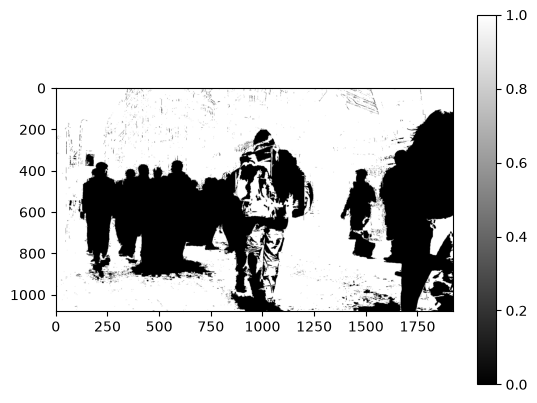

In [142]:
plt.imshow(f_gray[0], cmap="gray")
plt.colorbar()

In [ ]:
# for frame, person_mask in zip(frames, person_masks):
#     background_mask = (person_mask == 0).astype(np.uint8)  # 1 = background, 0 = person
#     frame_masked = frame * background_mask[..., None]      # zero out person pixels
#     frames_masked.append(frame_masked)
#     background_masks.append(background_mask.astype(np.int8))
# return np.asarray(frames_masked), np.asarray(background_masks)

Text(0.5, 1.0, 'After (holes filled)')

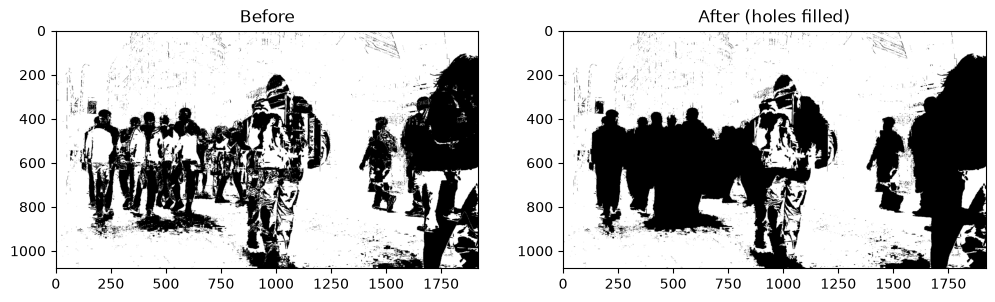

In [116]:
from scipy.ndimage import binary_fill_holes

NOISE_THRESHOLD = 15.0
img_grey = cv2.cvtColor(f_diff[0], cv2.COLOR_BGR2GRAY)
img_mask = np.where(img_grey > NOISE_THRESHOLD, 1, 0).astype(np.uint8)
img_mask = 1 - img_mask  # 1 = background, 0 = person

# Person pixels are 0, so treat "person == True" as the shape to fill holes in
person_mask = (img_mask == 0)
person_filled = binary_fill_holes(person_mask)

img_mask_filled = np.where(person_filled, 0, 1).astype(np.uint8)

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(img_mask, cmap="gray")
ax[0].set_title("Before")
ax[1].imshow(img_mask_filled, cmap="gray")
ax[1].set_title("After (holes filled)")

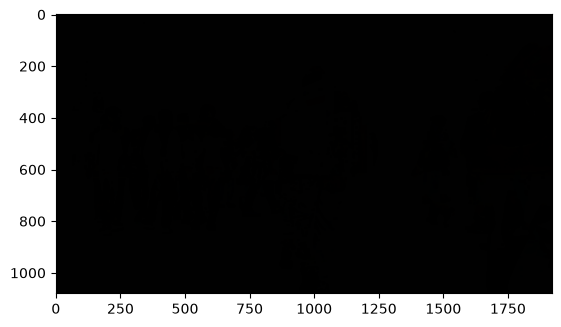

In [86]:
_, img = cv2.threshold(f_diff[0], 50, 1, cv2.THRESH_BINARY_INV) # 0 if pixel is moving (trigger thresh)
plt.imshow(img)

In [ ]:
# frames_masked = []
# background_masks = []
# for frame, person_mask in zip(frames, person_masks):
#     background_mask = (person_mask == 0).astype(np.uint8)  # 1 = background, 0 = person
#     frame_masked = frame * background_mask[..., None]      # zero out person pixels
#     frames_masked.append(frame_masked)
#     background_masks.append(background_mask.astype(np.int8))


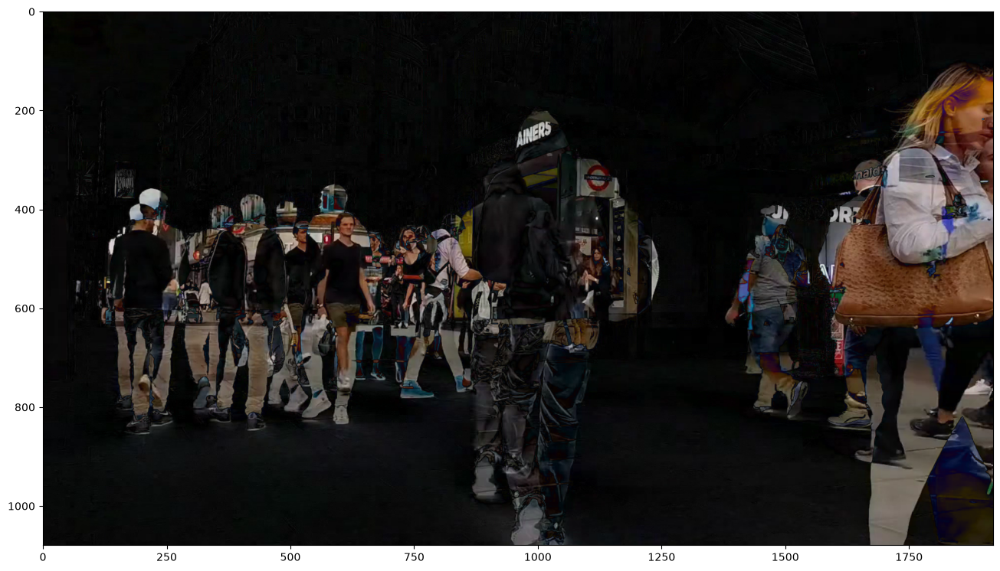

In [58]:
plt.figure(figsize=(16, 10))
plt.imshow(cv2.cvtColor(f_diff[0], cv2.COLOR_BGR2RGB))